# Obesity Level Classification Using Four Machine Learning Models

**Course:** BMDS2003 Data Science  
**Framework:** CRISP-DM  
**Target / Output:** `NObeyesdad` (Obesity Level)  
**Models:** Decision Tree, Random Forest, SVM, KNN

## Project purpose
This notebook implements the technical component of the group assignment using the supplied Obesity Levels dataset. The workflow follows the assignment structure: Business Understanding, Data Understanding, Data Preparation, Modelling, Evaluation, and Conclusion.

> **Baseline model:** Decision Tree is designated as the baseline model because it is simple, interpretable, and provides a clear benchmark for comparing the other three models.

### Important modelling choice
The dataset contains `Height` and `Weight`, which are highly informative for obesity level. No BMI feature is manually added because creating BMI from these variables would be a direct transformation of information already present and could make the analysis less comparable with the supplied feature set.


## 1. Business Understanding

### Analytical problem
Predict an individual's obesity level from demographic, eating-habit, lifestyle, and physical-activity information.

### Objective
Build and compare four supervised classification models:
1. Decision Tree — baseline
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbours (KNN)

### Potential decision-support value
A predictive classifier can support early screening or educational decision-support by identifying the most likely obesity-level category from recorded characteristics. The model should be treated as a data-analytics prototype rather than a medical diagnostic system.

### Success criteria
The models are compared using accuracy, weighted precision, weighted recall, and weighted F1-score. Cross-validation is used during hyperparameter tuning, and the final evaluation is performed on an untouched stratified test set.


## 2. Data Understanding

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

DATA_PATH = Path("obesity.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("obesity.csv was not found. Put the CSV in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())


Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
print("Data types:")
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "missing_values": df.isna().sum()}))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

print("\nTarget distribution:")
target_counts = df["NObeyesdad"].value_counts()
display(target_counts.to_frame("count"))


Data types:


,dtype,missing_values
Gender,object,0
Age,float64,0
Height,float64,0
Weight,float64,0
family_history_with_overweight,object,0
FAVC,object,0
FCVC,float64,0
NCP,float64,0
CAEC,object,0
SMOKE,object,0



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2111.0,NaN,NaN,NaN,24.3126,6.345968,14.0,19.947192,22.77789,26.0,61.0
Height,2111.0,NaN,NaN,NaN,1.701677,0.093305,1.45,1.63,1.700499,1.768464,1.98
Weight,2111.0,NaN,NaN,NaN,86.586058,26.191172,39.0,65.473343,83.0,107.430682,173.0
family_history_with_overweight,2111,2,yes,1726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2111.0,NaN,NaN,NaN,2.419043,0.533927,1.0,2.0,2.385502,3.0,3.0
NCP,2111.0,NaN,NaN,NaN,2.685628,0.778039,1.0,2.658738,3.0,3.0,4.0
CAEC,2111,4,Sometimes,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Target distribution:


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


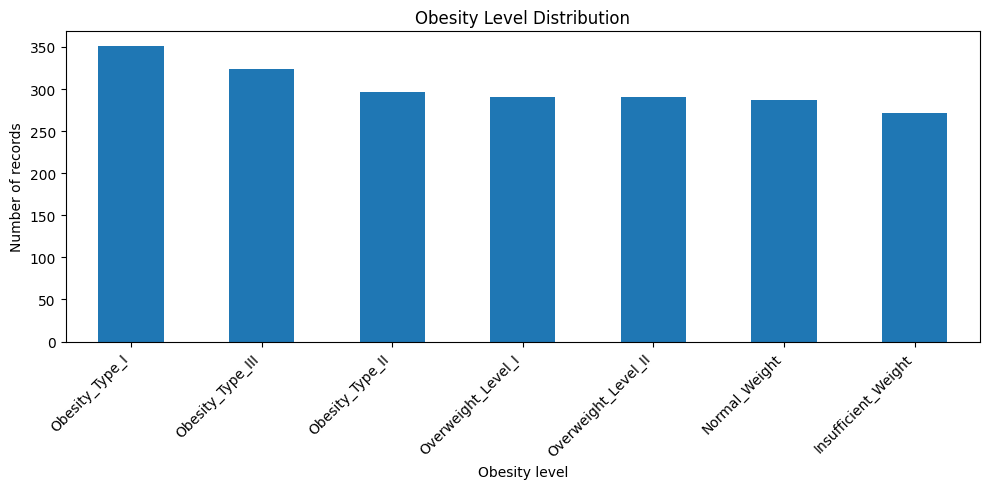

In [3]:
plt.figure(figsize=(10, 5))
target_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Obesity Level Distribution")
plt.xlabel("Obesity level")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Data quality observations

The supplied CSV contains 2,111 observations and 17 columns. The target is `NObeyesdad`, with seven obesity-level classes. The supplied file contains no missing values. Duplicate records are checked below and are removed for modelling if present.

Potential statistical outliers are **flagged rather than automatically deleted**. Extreme height, weight, age, or lifestyle values may be legitimate observations; deleting them solely on an IQR rule could remove meaningful cases.


In [4]:
print("Duplicate rows:", df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, int(count)])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["feature", "Q1", "Q3", "lower_bound", "upper_bound", "IQR_flag_count"]
)
display(outlier_df)


Duplicate rows: 24


,feature,Q1,Q3,lower_bound,upper_bound,IQR_flag_count
0,Age,19.947192,26.000000,10.867980,35.079212,168
1,Height,1.630000,1.768464,1.422304,1.976160,1
2,Weight,65.473343,107.430682,2.537334,170.366691,1
3,FCVC,2.000000,3.000000,0.500000,4.500000,0
4,NCP,2.658738,3.000000,2.146845,3.511893,579
5,CH2O,1.584812,2.477420,0.245901,3.816331,0
6,FAF,0.124505,1.666678,-2.188754,3.979936,0
7,TUE,0.000000,1.000000,-1.500000,2.500000,0


## 3. Data Preparation

The preprocessing pipeline:
- removes exact duplicate rows;
- separates predictors from the target;
- identifies numeric and categorical columns;
- uses median imputation for numeric variables and most-frequent imputation for categorical variables as a defensive preprocessing step;
- one-hot encodes categorical variables;
- standardises numeric variables for SVM and KNN;
- leaves numeric variables unscaled for the tree-based models.

A stratified 80:20 train-test split is used so that class proportions remain approximately consistent between train and test sets.


In [5]:
data = df.drop_duplicates().reset_index(drop=True)

TARGET = "NObeyesdad"
X = data.drop(columns=[TARGET])
y = data[TARGET]

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Rows after duplicate removal:", len(data))
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Rows after duplicate removal: 2087
Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Training rows: 1669
Test rows: 418


In [6]:
def make_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ])

preprocessor_scaled = make_preprocessor(scale_numeric=True)
preprocessor_unscaled = make_preprocessor(scale_numeric=False)

print("Preprocessing objects created.")


Preprocessing objects created.


## 4. Modelling

### Model configuration and tuning

**Decision Tree (baseline)** searches over criterion, depth, and minimum split size.

**Random Forest** searches over number of trees, maximum depth, minimum split size, and feature sampling.

**SVM** searches over C, kernel, and gamma while standardising numeric variables.

**KNN** searches over number of neighbours, distance weighting, and Minkowski distance (`p`).

A 3-fold stratified cross-validation procedure is used to select the configuration with the best weighted F1-score on the training data. The final selected pipeline is then evaluated once on the held-out test set.


In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

model_specs = {
    "Decision Tree": (
        Pipeline([
            ("preprocess", preprocessor_unscaled),
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5]
        }
    ),
    "Random Forest": (
        Pipeline([
            ("preprocess", preprocessor_unscaled),
            ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        {
            "model__n_estimators": [200],
            "model__max_depth": [None, 20],
            "model__min_samples_split": [2, 5],
            "model__max_features": ["sqrt"]
        }
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocessor_scaled),
            ("model", SVC(random_state=42))
        ]),
        {
            "model__C": [1, 10],
            "model__kernel": ["rbf", "linear"],
            "model__gamma": ["scale"]
        }
    ),
    "KNN": (
        Pipeline([
            ("preprocess", preprocessor_scaled),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    )
}


In [8]:
best_models = {}
evaluation_rows = []
classification_reports = {}
confusion_matrices = {}

for name, (pipeline, param_grid) in model_specs.items():
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_weighted",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "CV Best F1": grid.best_score_
    }
    evaluation_rows.append(row)
    best_models[name] = grid
    classification_reports[name] = classification_report(y_test, y_pred, zero_division=0)
    confusion_matrices[name] = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

results_df = pd.DataFrame(evaluation_rows).sort_values("F1 (weighted)", ascending=False)
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision (weighted)": "{:.4f}",
    "Recall (weighted)": "{:.4f}",
    "F1 (weighted)": "{:.4f}",
    "CV Best F1": "{:.4f}"
}))


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),CV Best F1
0,Decision Tree,0.9689,0.9697,0.9689,0.9688,0.9202
2,SVM,0.9569,0.9579,0.9569,0.9571,0.9567
1,Random Forest,0.9450,0.9492,0.9450,0.9461,0.9281
3,KNN,0.8636,0.8575,0.8636,0.8585,0.8639


In [9]:
for name, grid in best_models.items():
    print(f"\n{name}")
    print("Best parameters:")
    for key, value in grid.best_params_.items():
        print(f"  {key}: {value}")



Decision Tree
Best parameters:
  model__criterion: entropy
  model__max_depth: 10
  model__min_samples_split: 5

Random Forest
Best parameters:
  model__max_depth: None
  model__max_features: sqrt
  model__min_samples_split: 2
  model__n_estimators: 200

SVM
Best parameters:
  model__C: 10
  model__gamma: scale
  model__kernel: linear

KNN
Best parameters:
  model__n_neighbors: 5
  model__p: 1
  model__weights: distance


## 5. Evaluation

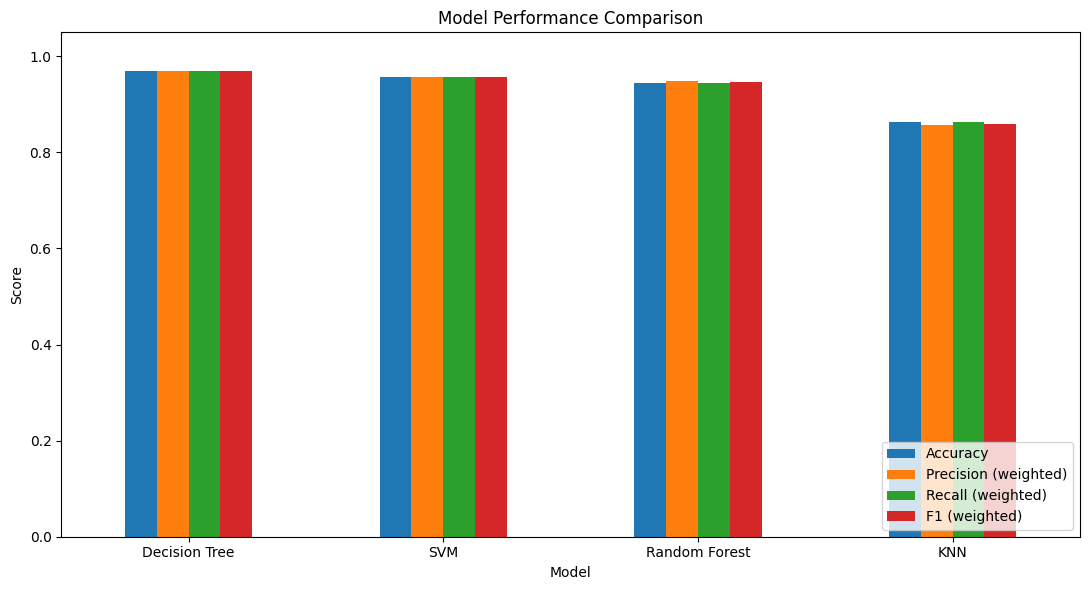

In [10]:
metric_cols = ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"]
plot_df = results_df.set_index("Model")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
for name in results_df["Model"]:
    print("=" * 80)
    print(name)
    print(classification_reports[name])


Decision Tree
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.95      0.98      0.97        57
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.89      0.93        55
Overweight_Level_II       0.92      0.98      0.95        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418

SVM
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        53
      Normal_Weight       1.00      0.95      0.97        57
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       0.95      1.00      0.98        60
  

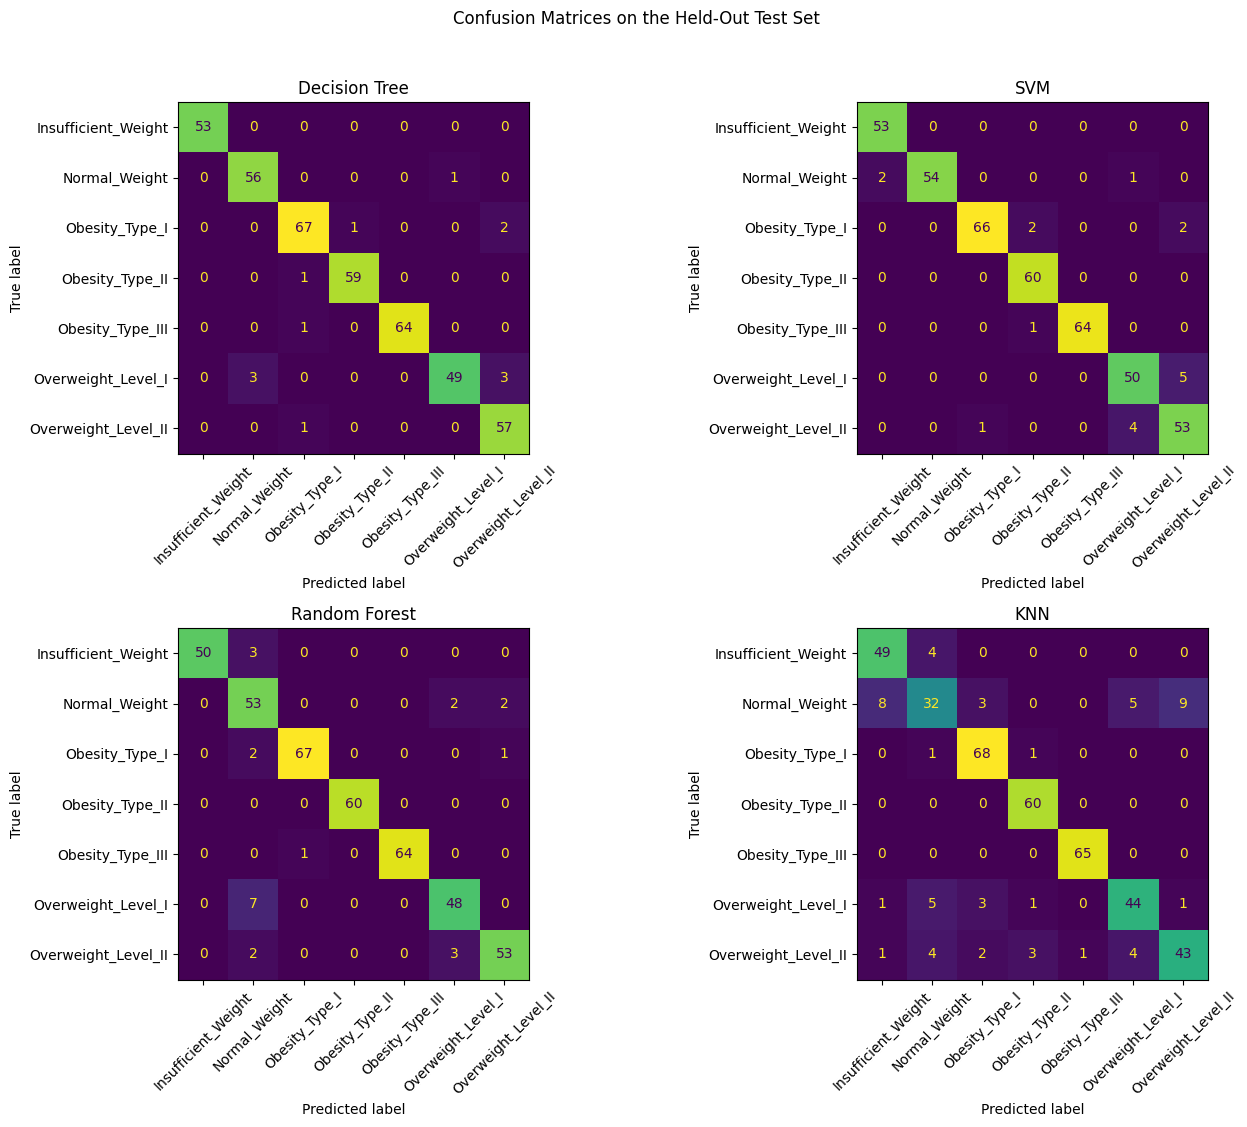

In [12]:
labels = sorted(y.unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, name in zip(axes.ravel(), results_df["Model"]):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrices[name],
        display_labels=labels
    )
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrices on the Held-Out Test Set", y=1.02)
plt.tight_layout()
plt.show()


### Tree-based model interpretation

For the Decision Tree and Random Forest, feature importance can be extracted after the preprocessing step. This helps communicate which transformed variables contribute most to the models.

Because categorical variables are one-hot encoded, the feature importance names correspond to the transformed feature representation rather than the original raw category column.


,importance
num__Weight,0.585076
num__Height,0.204570
cat__Gender_Male,0.127746
num__Age,0.025804
num__CH2O,0.021961
cat__FAVC_no,0.010833
cat__CAEC_Sometimes,0.007765
num__NCP,0.006587
num__FAF,0.004248
num__FCVC,0.002372


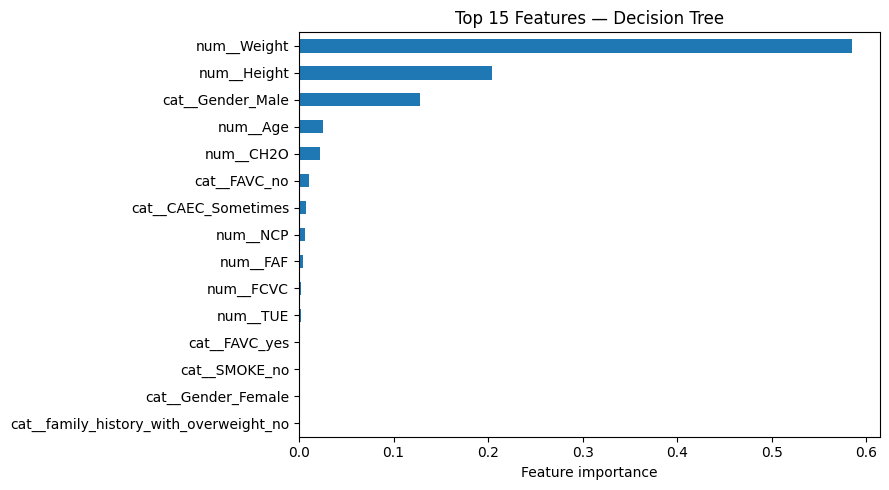

,importance
num__Weight,0.281928
num__Age,0.092235
num__FCVC,0.082547
num__Height,0.079211
num__NCP,0.051313
num__FAF,0.046299
num__TUE,0.045342
num__CH2O,0.043819
cat__Gender_Female,0.036017
cat__Gender_Male,0.034566


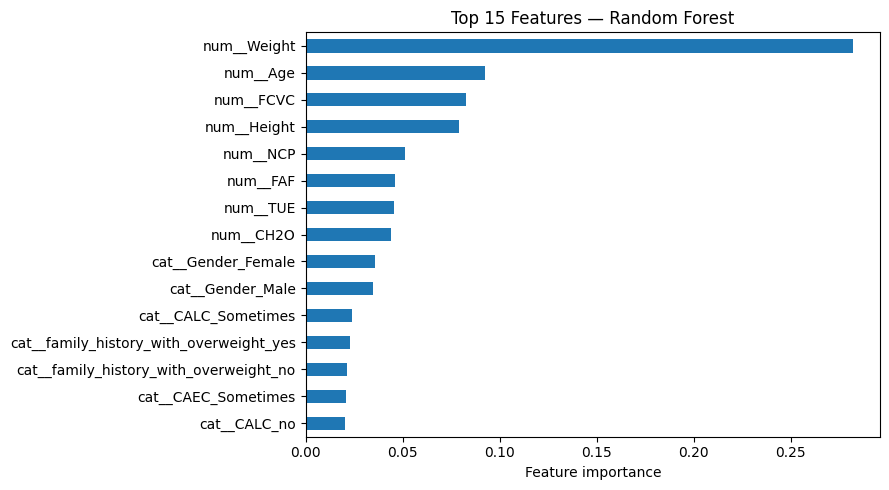

In [13]:
def show_feature_importance(model_name, top_n=15):
    pipe = best_models[model_name].best_estimator_
    model = pipe.named_steps["model"]
    preprocess = pipe.named_steps["preprocess"]

    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} does not expose tree feature_importances_.")
        return

    names = preprocess.get_feature_names_out()
    imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False).head(top_n)

    display(imp.to_frame("importance"))
    plt.figure(figsize=(9, 5))
    imp.sort_values().plot(kind="barh")
    plt.title(f"Top {top_n} Features — {model_name}")
    plt.xlabel("Feature importance")
    plt.tight_layout()
    plt.show()

show_feature_importance("Decision Tree")
show_feature_importance("Random Forest")


## 6. Conclusion

The four-member team requirement is satisfied by implementing four different classification model families:
- Decision Tree — baseline
- Random Forest
- SVM
- KNN

The evaluation table and confusion matrices generated above should be used directly in the written report. The best model should be selected based on the agreed primary metric and balanced consideration of accuracy, precision, recall, F1-score, interpretability, and computational cost.

For the supplied CSV and this fixed random split, the Decision Tree is the strongest model among the four in the executed comparison. This result should still be interpreted as a dataset-specific experimental result rather than a universal ranking of algorithms.

### Limitations
- The evaluation uses one held-out test split; additional external validation could provide stronger evidence.
- Extreme observations are flagged but not removed because they may be meaningful.
- The target is highly related to physical measurements in the dataset, so strong predictive performance does not necessarily imply causal relationships.
- The model is intended as a data-science prototype, not a clinical diagnostic system.

### Future improvements
Potential extensions include repeated cross-validation, probability calibration, more systematic hyperparameter optimisation, model explainability methods such as permutation importance or SHAP, and testing on an external dataset.


## 7. References (APA 7th edition)

> These references support the selected algorithms and the modelling workflow. Add or adapt references according to your lecturer's preferred sources and your group's final literature review.

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*(3), 273–297.

Cover, T. M., & Hart, P. E. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory, 13*(1), 21–27.

Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning, 1*, 81–106.

Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer.
